# Estimating univariate models

https://lifelines.readthedocs.io/en/latest/Survival%20analysis%20with%20lifelines.html

In [1]:
from lifelines.datasets import load_dd

data = load_dd()
data.head()

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
0,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1946.1952.Mona...,Non-democracy,Monarchy,1946,7,1
1,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1953.1962.Ci...,Non-democracy,Civilian Dict,1953,10,1
2,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1963.1972.Mona...,Non-democracy,Monarchy,1963,10,1
3,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1973.1977.Ci...,Non-democracy,Civilian Dict,1973,5,0
4,Afghanistan,700,700.0,Southern Asia,Asia,Nur Mohammad Taraki,Nur Mohammad Taraki.Afghanistan.1978.1978.Civi...,Non-democracy,Civilian Dict,1978,1,0


In [2]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

In [3]:
T = data["duration"]
E = data["observed"]

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1808 total observations, 340 right-censored observations>

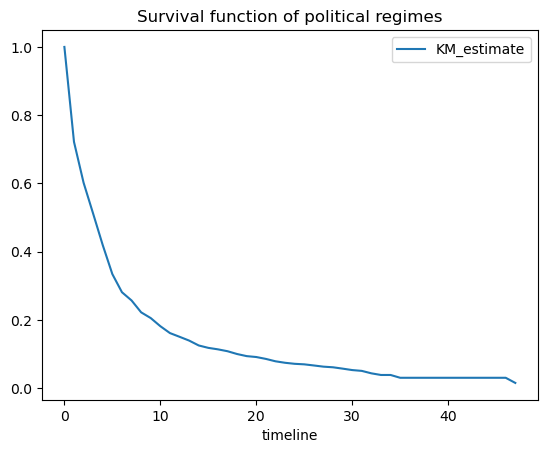

In [4]:
from matplotlib import pyplot as plt


kmf.survival_function_.plot()
plt.title('Survival function of political regimes');

<Axes: xlabel='timeline'>

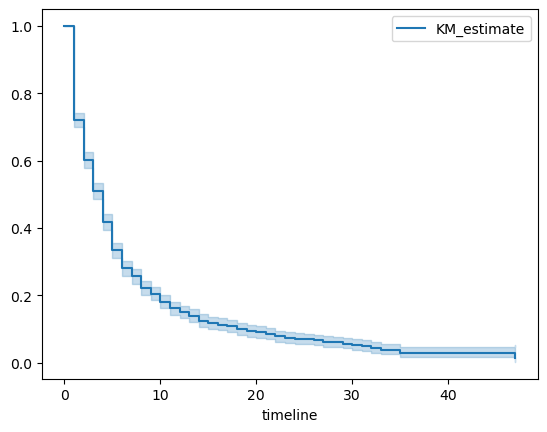

In [5]:
kmf.plot_survival_function()


In [6]:
kmf.median_survival_time_


4.0

In [7]:
from lifelines.utils import median_survival_times
median_ci = median_survival_times(kmf.confidence_interval_)

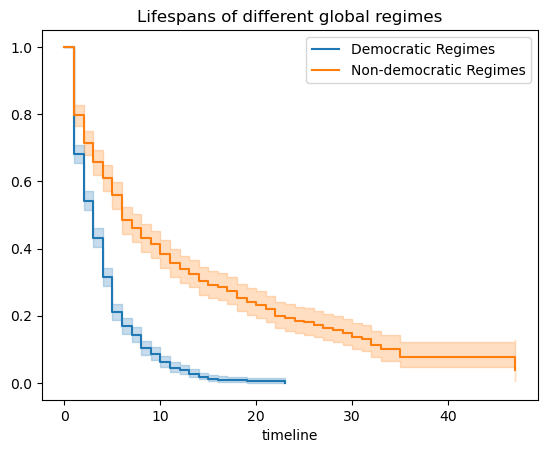

In [8]:
ax = plt.subplot(111)

dem = (data["democracy"] == "Democracy")

kmf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
kmf.plot_survival_function(ax=ax)

kmf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
kmf.plot_survival_function(ax=ax)

plt.title("Lifespans of different global regimes");

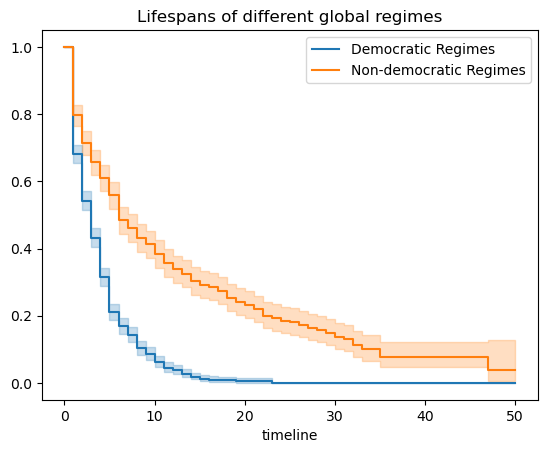

In [9]:
import numpy as np

ax = plt.subplot(111)

t = np.linspace(0, 50, 51)
kmf.fit(T[dem], event_observed=E[dem], timeline=t, label="Democratic Regimes")
ax = kmf.plot_survival_function(ax=ax)

kmf.fit(T[~dem], event_observed=E[~dem], timeline=t, label="Non-democratic Regimes")
ax = kmf.plot_survival_function(ax=ax)

plt.title("Lifespans of different global regimes");

In [10]:
from lifelines.statistics import logrank_test

results = logrank_test(T[dem], T[~dem], E[dem], E[~dem], alpha=.99)

results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         260.47 <0.005    192.23

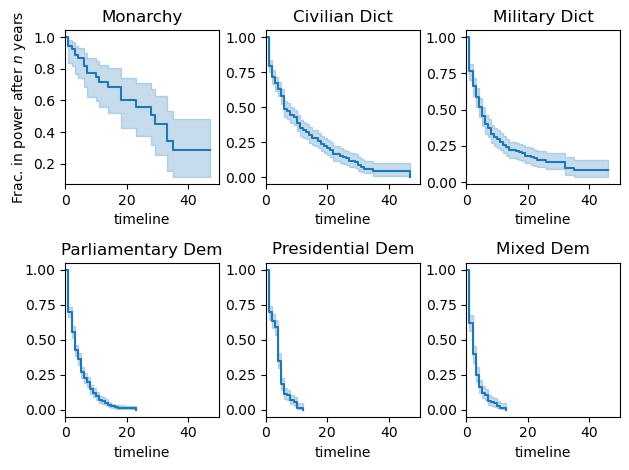

In [11]:
regime_types = data['regime'].unique()

for i, regime_type in enumerate(regime_types):
    ax = plt.subplot(2, 3, i + 1)

    ix = data['regime'] == regime_type
    kmf.fit(T[ix], E[ix], label=regime_type)
    kmf.plot_survival_function(ax=ax, legend=False)

    plt.title(regime_type)
    plt.xlim(0, 50)

    if i==0:
        plt.ylabel('Frac. in power after $n$ years')

plt.tight_layout()

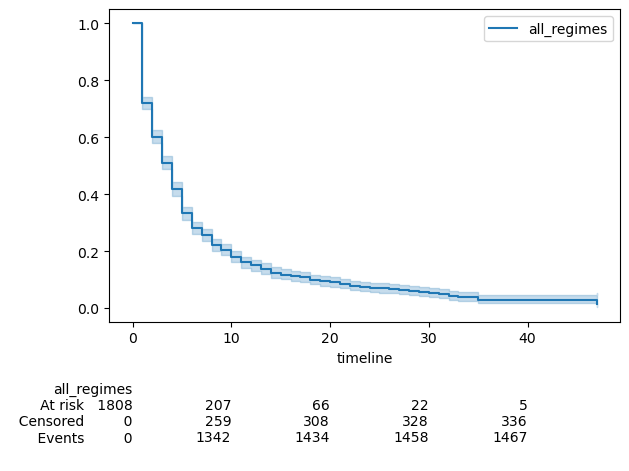

In [12]:
kmf = KaplanMeierFitter().fit(T, E, label="all_regimes")
kmf.plot_survival_function(at_risk_counts=True)
plt.tight_layout()

In [13]:
# T = [0, 3, 3, 2, 1, 2]
# E = [1, 1, 0, 0, 1, 1]
# kmf.fit(T, event_observed=E)

In [14]:
from lifelines.utils import datetimes_to_durations

start_date = ['2013-10-10 0:00:00', '2013-10-09', '2013-10-10']
end_date = ['2013-10-13', '2013-10-10', None]
T, E = datetimes_to_durations(start_date, end_date, fill_date='2013-10-15')
print('T (durations): ', T)
print('E (event_observed): ', E)

ValueError: time data "2013-10-09" doesn't match format "%Y-%m-%d %H:%M:%S", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
T = data["duration"]
E = data["observed"]

from lifelines import NelsonAalenFitter
naf = NelsonAalenFitter()

naf.fit(T,event_observed=E)

In [ ]:
print(naf.cumulative_hazard_.head())
naf.plot_cumulative_hazard()

In [ ]:
naf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
ax = naf.plot_cumulative_hazard(loc=slice(0, 20))

naf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
naf.plot_cumulative_hazard(ax=ax, loc=slice(0, 20))

plt.title("Cumulative hazard function of different global regimes");

In [ ]:
bandwidth = 3.

naf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
ax = naf.plot_hazard(bandwidth=bandwidth)

naf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
naf.plot_hazard(ax=ax, bandwidth=bandwidth)

plt.title("Hazard function of different global regimes | bandwidth=%.1f" % bandwidth);
plt.ylim(0, 0.4)
plt.xlim(0, 25);

In [ ]:
bandwidth = 8.0

naf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
ax = naf.plot_hazard(bandwidth=bandwidth)

naf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
naf.plot_hazard(ax=ax, bandwidth=bandwidth)

plt.title("Hazard function of different global regimes | bandwidth=%.1f" % bandwidth);

In [ ]:
from lifelines import WeibullFitter
from lifelines.datasets import load_waltons

data = load_waltons()

T = data['T']
E = data['E']

wf = WeibullFitter().fit(T, E)

wf.print_summary()
ax = wf.plot_cumulative_hazard()
ax.set_title("Cumulative hazard of Weibull model; estimated parameters")


In [ ]:
from lifelines import (WeibullFitter, ExponentialFitter,
LogNormalFitter, LogLogisticFitter, NelsonAalenFitter,
PiecewiseExponentialFitter, GeneralizedGammaFitter, SplineFitter)

from lifelines.datasets import load_waltons
data = load_waltons()

fig, axes = plt.subplots(3, 3, figsize=(10, 7.5))

T = data['T']
E = data['E']

wbf = WeibullFitter().fit(T, E, label='WeibullFitter')
exf = ExponentialFitter().fit(T, E, label='ExponentialFitter')
lnf = LogNormalFitter().fit(T, E, label='LogNormalFitter')
naf = NelsonAalenFitter().fit(T, E, label='NelsonAalenFitter')
llf = LogLogisticFitter().fit(T, E, label='LogLogisticFitter')
pwf = PiecewiseExponentialFitter([40, 60]).fit(T, E, label='PiecewiseExponentialFitter')
gg = GeneralizedGammaFitter().fit(T, E, label='GeneralizedGammaFitter')
spf = SplineFitter([6, 20, 40, 75]).fit(T, E, label='SplineFitter')

wbf.plot_cumulative_hazard(ax=axes[0][0])
exf.plot_cumulative_hazard(ax=axes[0][1])
lnf.plot_cumulative_hazard(ax=axes[0][2])
naf.plot_cumulative_hazard(ax=axes[1][0])
llf.plot_cumulative_hazard(ax=axes[1][1])
pwf.plot_cumulative_hazard(ax=axes[1][2])
gg.plot_cumulative_hazard(ax=axes[2][0])
spf.plot_cumulative_hazard(ax=axes[2][1])

In [ ]:
from lifelines import KaplanMeierFitter

fig, axes = plt.subplots(3, 3, figsize=(10, 7.5))

T = data['T']
E = data['E']

kmf = KaplanMeierFitter().fit(T, E, label='KaplanMeierFitter')
wbf = WeibullFitter().fit(T, E, label='WeibullFitter')
exf = ExponentialFitter().fit(T, E, label='ExponentialFitter')
lnf = LogNormalFitter().fit(T, E, label='LogNormalFitter')
llf = LogLogisticFitter().fit(T, E, label='LogLogisticFitter')
pwf = PiecewiseExponentialFitter([40, 60]).fit(T, E, label='PiecewiseExponentialFitter')
gg = GeneralizedGammaFitter().fit(T, E, label='GeneralizedGammaFitter')
spf = SplineFitter([6, 20, 40, 75]).fit(T, E, label='SplineFitter')

wbf.plot_survival_function(ax=axes[0][0])
exf.plot_survival_function(ax=axes[0][1])
lnf.plot_survival_function(ax=axes[0][2])
kmf.plot_survival_function(ax=axes[1][0])
llf.plot_survival_function(ax=axes[1][1])
pwf.plot_survival_function(ax=axes[1][2])
gg.plot_survival_function(ax=axes[2][0])
spf.plot_survival_function(ax=axes[2][1])

In [ ]:
timeline = np.linspace(0, 100, 200)

# directly compute the survival function, these return a pandas Series
wbf = WeibullFitter().fit(T, E)
wbf.survival_function_at_times(timeline)
wbf.hazard_at_times(timeline)
wbf.cumulative_hazard_at_times(timeline)

# use the `timeline` kwarg in `fit`
# by default, all functions and properties will use
# these values provided
wbf = WeibullFitter().fit(T, E, timeline=timeline)

ax = wbf.plot_survival_function()
ax.set_title("Survival function of Weibull model; estimated parameters")

In [ ]:
from lifelines.datasets import load_nh4
df = load_nh4()[['NH4.Orig.mg.per.L', 'NH4.mg.per.L', 'Censored']]
print(df.head())


In [ ]:
T, E = df['NH4.mg.per.L'], ~df['Censored']

kmf = KaplanMeierFitter()
kmf.fit_left_censoring(T, E)

In [ ]:
print(kmf.cumulative_density_.head())

kmf.plot_cumulative_density() #will plot the CDF
plt.xlabel("Concentration of NH_4")

In [ ]:
from lifelines import *
from lifelines.plotting import qq_plot

fig, axes = plt.subplots(3, 2, figsize=(9, 9))
timeline = np.linspace(0, 0.25, 100)

wf = WeibullFitter().fit_left_censoring(T, E, label="Weibull", timeline=timeline)
lnf = LogNormalFitter().fit_left_censoring(T, E, label="Log Normal", timeline=timeline)
lgf = LogLogisticFitter().fit_left_censoring(T, E, label="Log Logistic", timeline=timeline)

# plot what we just fit, along with the KMF estimate
kmf.plot_cumulative_density(ax=axes[0][0], ci_show=False)
wf.plot_cumulative_density(ax=axes[0][0], ci_show=False)
qq_plot(wf, ax=axes[0][1])

kmf.plot_cumulative_density(ax=axes[1][0], ci_show=False)
lnf.plot_cumulative_density(ax=axes[1][0], ci_show=False)
qq_plot(lnf, ax=axes[1][1])

kmf.plot_cumulative_density(ax=axes[2][0], ci_show=False)
lgf.plot_cumulative_density(ax=axes[2][0], ci_show=False)
qq_plot(lgf, ax=axes[2][1])

In [ ]:
from lifelines.datasets import load_diabetes
from lifelines.plotting import plot_interval_censored_lifetimes

df = load_diabetes()
plot_interval_censored_lifetimes(df['left'], df['right'])

In [ ]:
wf = WeibullFitter()
wf.fit_interval_censoring(lower_bound=df['left'], upper_bound=df['right'])

# or, a non-parametric estimator:
# for now, this assumes closed observation intervals, ex: [4,5], not (4, 5) or (4, 5]
kmf = KaplanMeierFitter()
kmf.fit_interval_censoring(df['left'], df['right'])

ax = kmf.plot_survival_function()
wf.plot_survival_function(ax=ax)

In [ ]:
from lifelines.datasets import load_multicenter_aids_cohort_study
from lifelines.plotting import plot_lifetimes

df = load_multicenter_aids_cohort_study()

plot_lifetimes(
    df["T"],
    event_observed=df["D"],
    entry=df["W"],
    event_observed_color="#383838",
    event_censored_color="#383838",
    left_truncated=True,
)
plt.ylabel("Patient Number")
plt.xlabel("Years from AIDS diagnosis")

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df["T"], event_observed=df["D"], entry=df["W"], label='modeling late entries')
ax = kmf.plot_survival_function()

kmf.fit(df["T"], event_observed=df["D"], label='ignoring late entries')
kmf.plot_survival_function(ax=ax)